# System Identification from Video-Derived Theta

Uses the beam angle extracted by our ResNet50 (DLC pipeline) as training data
for the `LinearPhysODE` model.

**Data sources:**
- `theta(t)`: from ResNet50 video inference (`theta_dlc_pytorch.csv`)
- `u(t)`: input voltage from the swept_sine .mat experiment

**Alignment:**
- The video starts ~9.7s before the experiment trigger
- The video theta has opposite sign convention (flipped)
- Scale factor ~1.34x due to pixel-to-angle calibration difference

In [18]:
import sys
from pathlib import Path

# Ensure project root is on the path (for bab, bab_datasets, etc.)
PROJECT_ROOT = str(Path("/Users/eg75agon/Downloads/Project_helon"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import bab_datasets as nod
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from torchdiffeq import odeint
import matplotlib.pyplot as plt

device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


## 1. Load and Align Video Theta with Experiment Input

In [19]:
working_dir = "/Users/eg75agon/Downloads/Project_helon"

# ── Load input/output from the swept_sine .mat file via bab_datasets ──
data = nod.load_experiment("swept_sine", resample_factor=33)  # ~30 Hz to match video
t_mat = data.time_vector()
u_mat = data.u
y_mat = data.y
print(f"Mat experiment: {len(t_mat)} samples, {t_mat[-1]:.2f}s at {1/data.sampling_time:.0f} Hz")

# ── Load video theta from ResNet50 ──
vid_df = pd.read_csv(f"{working_dir}/theta_dlc_pytorch.csv")
t_vid = vid_df["t_s"].values
y_vid_raw = vid_df["theta_deg"].values
print(f"Video theta: {len(t_vid)} frames, {t_vid[-1]:.2f}s at 30 fps")

Mat experiment: 1667 samples, 54.98s at 30 Hz
Video theta: 2129 frames, 70.93s at 30 fps


In [20]:
# ── Temporal alignment via cross-correlation ──
# Video theta has OPPOSITE SIGN convention (camera angle vs sensor)
y_vid_flipped = -y_vid_raw

def neg_corr(offset):
    mask = (t_vid >= offset) & (t_vid - offset <= t_mat[-1])
    if mask.sum() < 100:
        return 0
    tv = t_vid[mask] - offset
    yv = y_vid_flipped[mask]
    ym = interp1d(t_mat, y_mat, kind="linear")(tv)
    return -np.corrcoef(ym, yv)[0, 1]

res = minimize_scalar(neg_corr, bounds=(8.0, 12.0), method="bounded")
VIDEO_OFFSET = res.x
print(f"Optimal offset: {VIDEO_OFFSET:.4f}s (experiment starts at video frame {int(VIDEO_OFFSET * 30)})")

# ── Extract aligned overlap region ──
overlap_mask = (t_vid >= VIDEO_OFFSET) & (t_vid - VIDEO_OFFSET <= t_mat[-1])
t_aligned = t_vid[overlap_mask] - VIDEO_OFFSET  # aligned to experiment time
y_video_raw = y_vid_flipped[overlap_mask]        # theta from video (sign-flipped, uncalibrated)

# Interpolate mat signals onto the video time grid (30 Hz)
u_aligned = interp1d(t_mat, u_mat, kind="linear")(t_aligned)
y_mat_aligned = interp1d(t_mat, y_mat, kind="linear")(t_aligned)

# ── Scale calibration: y_video has a multiplicative + offset mismatch ──
# Fit:  y_mat ≈ alpha * y_video_raw + beta
A = np.column_stack([y_video_raw, np.ones(len(y_video_raw))])
(alpha, beta), _, _, _ = np.linalg.lstsq(A, y_mat_aligned, rcond=None)
y_video = alpha * y_video_raw + beta  # calibrated video theta

corr_before = np.corrcoef(y_mat_aligned, y_video_raw)[0, 1]
corr_after = np.corrcoef(y_mat_aligned, y_video)[0, 1]
rmse_before = np.sqrt(np.mean((y_mat_aligned - y_video_raw) ** 2))
rmse_after = np.sqrt(np.mean((y_mat_aligned - y_video) ** 2))

print(f"\nScale calibration: y_sensor = {alpha:.4f} * y_video + {beta:.4f}")
print(f"  Before calibration: corr={corr_before:.4f}, RMSE={rmse_before:.4f} deg")
print(f"  After  calibration: corr={corr_after:.4f}, RMSE={rmse_after:.4f} deg")
print(f"Overlap: {len(t_aligned)} samples, {t_aligned[-1]:.2f}s at Ts={np.mean(np.diff(t_aligned)):.4f}s")

Optimal offset: 9.6944s (experiment starts at video frame 290)

Scale calibration: y_sensor = 0.7278 * y_video + -0.8762
  Before calibration: corr=0.9997, RMSE=1.6512 deg
  After  calibration: corr=0.9997, RMSE=0.0800 deg
Overlap: 1650 samples, 54.97s at Ts=0.0333s


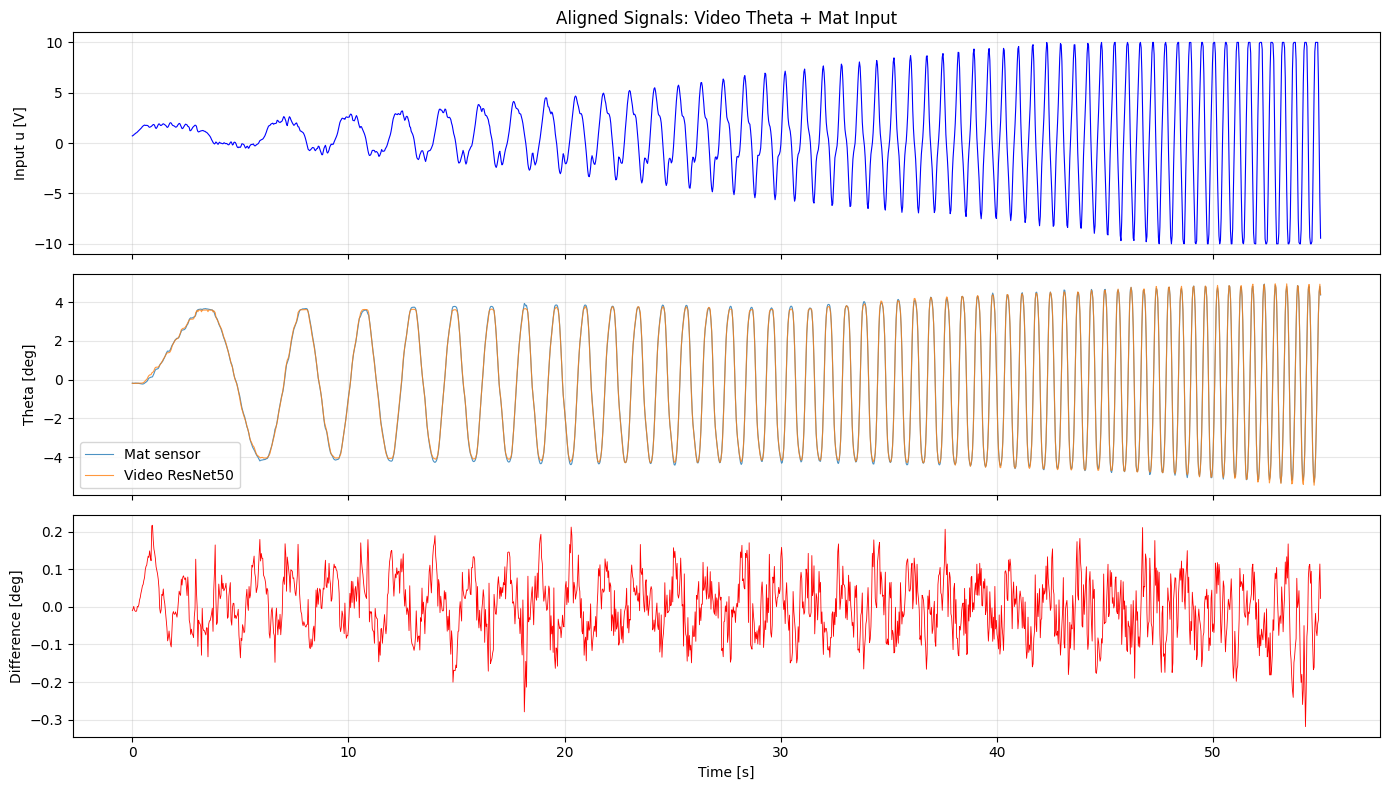

In [21]:
# ── Visualize alignment ──
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t_aligned, u_aligned, linewidth=0.8, color="blue")
axes[0].set_ylabel("Input u [V]")
axes[0].set_title("Aligned Signals: Video Theta + Mat Input")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_aligned, y_mat_aligned, linewidth=0.8, label="Mat sensor", alpha=0.8)
axes[1].plot(t_aligned, y_video, linewidth=0.8, label="Video ResNet50", alpha=0.8)
axes[1].set_ylabel("Theta [deg]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_aligned, y_video - y_mat_aligned, linewidth=0.6, color="red")
axes[2].set_ylabel("Difference [deg]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Prepare Training Data

In [22]:
# ── Resample to a uniform grid matching the existing pipeline ──
# The original pipeline uses resample_factor=50 -> ~20 Hz from 1kHz
# Our video is at 30 Hz. We'll use the video sampling rate directly.
velMethod = "central"

t = t_aligned
u = u_aligned
y = y_video  # theta from ResNet50
Ts = float(np.round(np.mean(np.diff(t)), 4))
fps = 1.0 / Ts

# Compute velocity using central differences
y_dot = np.gradient(y, Ts)
y_sim = np.column_stack([y, y_dot])

print(f"Training data:")
print(f"  Samples: {len(u)}")
print(f"  Duration: {t[-1]:.2f}s")
print(f"  Ts: {Ts:.4f}s ({fps:.1f} Hz)")
print(f"  u range: [{u.min():.2f}, {u.max():.2f}]")
print(f"  y range: [{y.min():.2f}, {y.max():.2f}] deg")
print(f"  y_dot range: [{y_dot.min():.2f}, {y_dot.max():.2f}] deg/s")

Training data:
  Samples: 1650
  Duration: 54.97s
  Ts: 0.0333s (30.0 Hz)
  u range: [-10.00, 10.00]
  y range: [-5.45, 4.95] deg
  y_dot range: [-70.10, 62.52] deg/s


In [23]:
# ── Convert to PyTorch tensors ──
t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
u_tensor = torch.tensor(u, dtype=torch.float32).reshape(-1, 1).to(device)
y_tensor = torch.tensor(y_sim, dtype=torch.float32).to(device)

# Single contiguous training segment
train_segments = [("video_swept_sine", 0, len(u))]

# Precompute valid k-step start indices
K_STEPS = 20
valid_train_start_idx = []
for _, s0, s1 in train_segments:
    if (s1 - s0) > K_STEPS:
        valid_train_start_idx.extend(range(s0, s1 - K_STEPS))
valid_train_start_idx = np.asarray(valid_train_start_idx, dtype=int)

print(f"Tensor shapes -> t: {tuple(t_tensor.shape)}, u: {tuple(u_tensor.shape)}, y: {tuple(y_tensor.shape)}")
print(f"Valid train starts: {len(valid_train_start_idx)}")

Tensor shapes -> t: (1650,), u: (1650, 1), y: (1650, 2)
Valid train starts: 1630


## 3. LinearPhysODE Model + Training

In [24]:
class LinearPhysODE(nn.Module):
    # J*thdd + R*thd + K*(th+delta) = Tau*V
    def __init__(self):
        super().__init__()
        self.log_J = nn.Parameter(torch.tensor(np.log(0.1), dtype=torch.float32))
        self.log_R = nn.Parameter(torch.tensor(np.log(0.1), dtype=torch.float32))
        self.log_K = nn.Parameter(torch.tensor(np.log(1.0), dtype=torch.float32))
        self.delta = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.log_Tau = nn.Parameter(torch.tensor(np.log(1.0), dtype=torch.float32))
        self.u_series = None
        self.t_series = None
        self.batch_start_times = None

    def get_params(self):
        J = torch.exp(self.log_J)
        R = torch.exp(self.log_R)
        K = torch.exp(self.log_K)
        Tau = torch.exp(self.log_Tau)
        return J, R, K, self.delta, Tau

    def forward(self, t, x):
        J, R, K, delta, Tau = self.get_params()
        if self.batch_start_times is not None:
            t_abs = self.batch_start_times + t
        else:
            t_abs = t * torch.ones_like(x[:, 0:1])

        k_idx = torch.searchsorted(self.t_series, t_abs.reshape(-1), right=True)
        k_idx = torch.clamp(k_idx, 1, len(self.t_series) - 1)
        t1, t2 = self.t_series[k_idx - 1].unsqueeze(1), self.t_series[k_idx].unsqueeze(1)
        u1, u2 = self.u_series[k_idx - 1], self.u_series[k_idx]
        denom = (t2 - t1)
        denom[denom < 1e-6] = 1.0
        alpha = (t_abs - t1) / denom
        u_t = u1 + alpha * (u2 - u1)

        th, thd = x[:, 0:1], x[:, 1:2]
        thdd = (Tau * u_t - R * thd - K * (th + delta)) / J
        return torch.cat([thd, thdd], dim=1)

In [25]:
def train_model_obs(model, name, epochs=500, lr=0.02, obs_dim=2):
    print(f"--- Training {name} ---")
    model.to(device)
    model.u_series = u_tensor
    model.t_series = t_tensor

    optimizer = optim.Adam(model.parameters(), lr=lr)
    BATCH_SIZE = 128
    dt_local = (t_tensor[1] - t_tensor[0]).item()
    t_eval = torch.arange(0, K_STEPS * dt_local, dt_local, device=device)

    losses = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()

        start_idx = np.random.choice(valid_train_start_idx, size=BATCH_SIZE, replace=True)
        x0 = y_tensor[start_idx]
        model.batch_start_times = t_tensor[start_idx].reshape(-1, 1)

        pred_state = odeint(model, x0, t_eval, method='rk4')
        pred_obs = pred_state[..., :obs_dim]

        batch_targets = []
        for i in start_idx:
            batch_targets.append(y_tensor[i:i + K_STEPS])
        y_target = torch.stack(batch_targets, dim=1)  # [T, B, 2]

        # Position-only loss (theta), velocity is used only as IC
        pred_pos = pred_obs[..., 0:1]
        target_pos = y_target[..., 0:1]
        loss = torch.mean((pred_pos - target_pos) ** 2)

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if epoch % 100 == 0:
            J, R, K, delta, Tau = model.get_params()
            print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f} | "
                  f"J={J.item():.4f} R={R.item():.4f} K={K.item():.4f} "
                  f"delta={delta.item():.4f} Tau={Tau.item():.4f}")

    return model, losses

In [26]:
lin_model = LinearPhysODE()
lin_model, losses = train_model_obs(lin_model, "Linear Model (Video Theta)", epochs=1000, lr=0.01)

--- Training Linear Model (Video Theta) ---
Epoch    0 | Loss: 28.941370 | J=0.0990 R=0.1010 K=1.0101 delta=0.0100 Tau=1.0101
Epoch  100 | Loss: 3.681063 | J=0.0494 R=0.2286 K=1.8959 delta=0.6577 Tau=1.6289
Epoch  200 | Loss: 1.611274 | J=0.0404 R=0.3654 K=1.8980 delta=0.8555 Tau=2.2515
Epoch  300 | Loss: 1.001704 | J=0.0383 R=0.4908 K=1.6519 delta=1.2057 Tau=2.9438
Epoch  400 | Loss: 0.720882 | J=0.0378 R=0.5964 K=1.4447 delta=1.6011 Tau=3.5227
Epoch  500 | Loss: 0.653860 | J=0.0380 R=0.6672 K=1.3086 delta=2.0167 Tau=3.9594
Epoch  600 | Loss: 0.464886 | J=0.0384 R=0.7256 K=1.2039 delta=2.3713 Tau=4.2198
Epoch  700 | Loss: 0.471609 | J=0.0388 R=0.7635 K=1.1348 delta=2.7087 Tau=4.4337
Epoch  800 | Loss: 0.368542 | J=0.0392 R=0.7960 K=1.0772 delta=2.9872 Tau=4.6530
Epoch  900 | Loss: 0.316416 | J=0.0395 R=0.8198 K=1.0331 delta=3.2460 Tau=4.8352
Epoch 1000 | Loss: 0.357702 | J=0.0398 R=0.8435 K=0.9987 delta=3.4852 Tau=4.9292


## 4. Evaluation

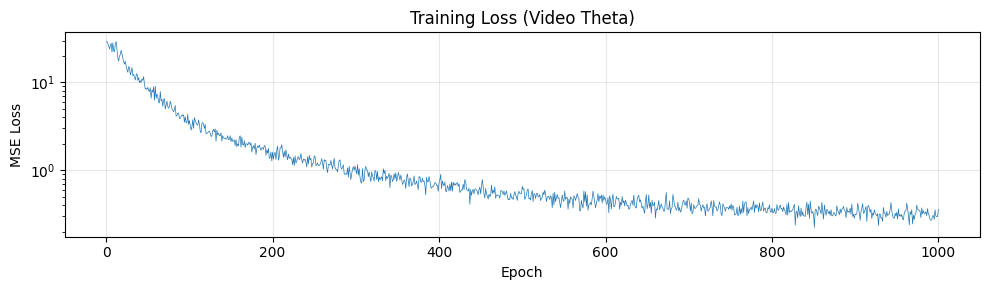

Identified parameters:
  J     = 0.039804
  R     = 0.843506
  K     = 0.998697
  delta = 3.485179
  Tau   = 4.929165


In [27]:
# ── Learning curve ──
fig, ax = plt.subplots(figsize=(10, 3))
ax.semilogy(losses, linewidth=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss (Video Theta)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Identified parameters ──
J, R, K, delta, Tau = lin_model.get_params()
print(f"Identified parameters:")
print(f"  J     = {J.item():.6f}")
print(f"  R     = {R.item():.6f}")
print(f"  K     = {K.item():.6f}")
print(f"  delta = {delta.item():.6f}")
print(f"  Tau   = {Tau.item():.6f}")

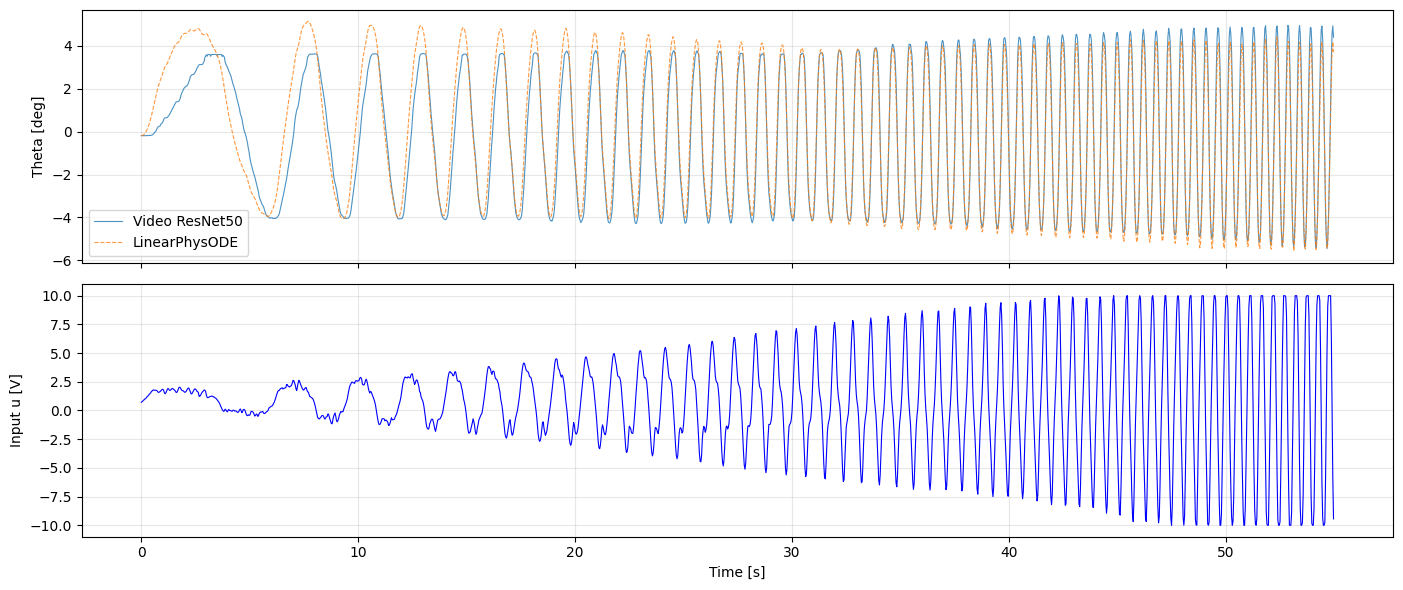

Saved: /Users/eg75agon/Downloads/Project_helon/figures/sysid_simulation.pdf
Full simulation RMSE: 0.9550 deg


In [28]:
# ── Full simulation vs measured ──
lin_model.eval()
lin_model.u_series = u_tensor
lin_model.t_series = t_tensor

# Simple approach: simulate the entire trajectory in one odeint call
with torch.no_grad():
    x0_sim = y_tensor[0:1]  # (1, 2) — initial [theta, theta_dot]
    lin_model.batch_start_times = t_tensor[0:1].reshape(1, 1)
    t_local = t_tensor - t_tensor[0]  # time relative to start
    pred = odeint(lin_model, x0_sim, t_local, method='rk4')  # (T, 1, 2)
    y_sim_arr = pred[:, 0].cpu().numpy()  # (T, 2)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, y, linewidth=0.8, label="Video ResNet50", alpha=0.8)
axes[0].plot(t, y_sim_arr[:, 0], linewidth=0.8, label="LinearPhysODE", alpha=0.8, linestyle="--")
axes[0].set_ylabel("Theta [deg]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, u, linewidth=0.8, color="blue")
axes[1].set_ylabel("Input u [V]")
axes[1].set_xlabel("Time [s]")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

fig_dir = Path(working_dir) / "figures"
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / "sysid_simulation.pdf", dpi=1200, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_dir / 'sysid_simulation.pdf'}")

# RMSE
rmse = np.sqrt(np.mean((y - y_sim_arr[:len(y), 0])**2))
print(f"Full simulation RMSE: {rmse:.4f} deg")